Libraries loaded successfully.
Data loaded: 252 rows and 53 columns.

Target Variable Distribution (0 = Low Intention, 1 = High Intention):
High_Adoption_Target
1    53.2
0    46.8
Name: proportion, dtype: float64

Training on 189 citizens. Testing on 48 citizens.

XGBoost Model Trained Successfully!

=== XGBOOST PERFORMANCE METRICS ===
Accuracy: 0.812 (Correctly predicted 81.2% of citizens)
ROC-AUC Score: 0.932 (Target > 0.75)

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81        22
           1       0.87      0.77      0.82        26

    accuracy                           0.81        48
   macro avg       0.81      0.82      0.81        48
weighted avg       0.82      0.81      0.81        48



/tmp/ipykernel_592/2011766537.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


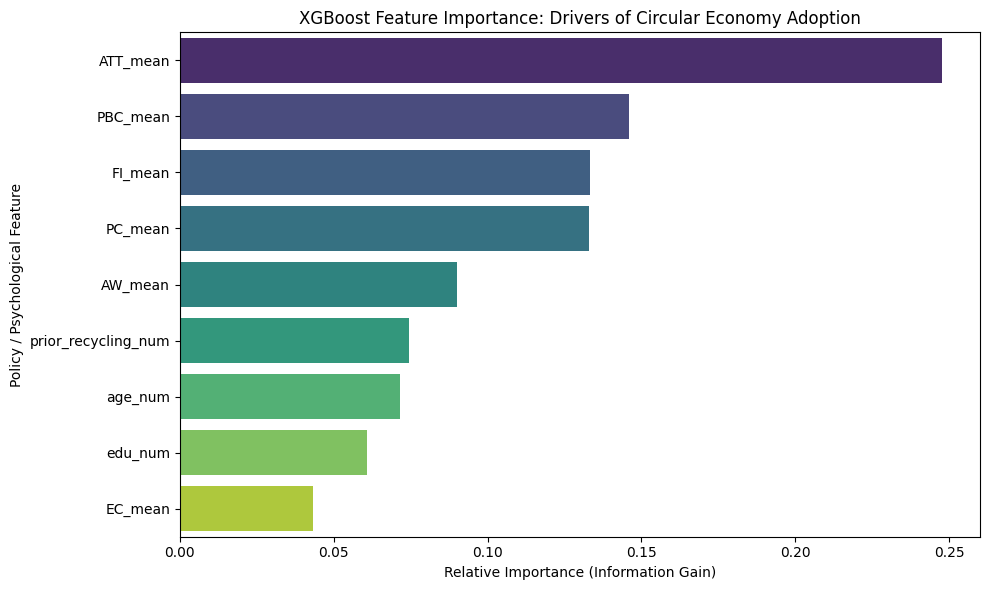


=== TOP 3 DRIVERS FOR POLICYMAKERS ===
 Feature  Importance
ATT_mean    0.247661
PBC_mean    0.146107
 FI_mean    0.133136


In [1]:
# ==============================================================================
# PHASE 7: MACHINE LEARNING IMPLEMENTATION (XGBOOST)
# Predicting Circular Economy Adoption (Recycling Intention)
# ==============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

# 1. LOAD THE CLEAN DATA FROM COLAB
# This path is updated to read the file uploaded to the Colab session
file_path = "survey_clean.csv"
df = pd.read_csv(file_path)

print(f"Data loaded: {df.shape[0]} rows and {df.shape[1]} columns.")

# 2. FEATURE ENGINEERING (Defining the Target Variable)
df['High_Adoption_Target'] = (df['RI_mean'] >= 3.5).astype(int)

print("\nTarget Variable Distribution (0 = Low Intention, 1 = High Intention):")
print(df['High_Adoption_Target'].value_counts(normalize=True).round(3) * 100)

# 3. SELECT PREDICTOR FEATURES
features = [
    'age_num', 'edu_num', 'prior_recycling_num',
    'EC_mean',   # Environmental Concern
    'AW_mean',   # Awareness
    'FI_mean',   # Financial Incentives
    'PC_mean',   # Privacy Concerns
    'ATT_mean',  # Attitude
    'PBC_mean'   # Perceived Behavioral Control
]

# Drop any rows that still have NAs in our feature set
df = df.dropna(subset=features + ['High_Adoption_Target'])

X = df[features]
y = df['High_Adoption_Target']

# 4. TRAIN / TEST SPLIT (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTraining on {X_train.shape[0]} citizens. Testing on {X_test.shape[0]} citizens.")

# 5. INITIALIZE AND TRAIN THE XGBOOST MODEL
xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    max_depth=4,
    learning_rate=0.1,
    n_estimators=100,
    reg_lambda=1.5
)

xgb_model.fit(X_train, y_train)
print("\nXGBoost Model Trained Successfully!")

# 6. EVALUATE THE MODEL ON UNSEEN TEST DATA
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n=== XGBOOST PERFORMANCE METRICS ===")
print(f"Accuracy: {accuracy:.3f} (Correctly predicted {accuracy*100:.1f}% of citizens)")
print(f"ROC-AUC Score: {roc_auc:.3f} (Target > 0.75)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. FEATURE IMPORTANCE (What drives the AI's predictions?)
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('XGBoost Feature Importance: Drivers of Circular Economy Adoption')
plt.xlabel('Relative Importance (Information Gain)')
plt.ylabel('Policy / Psychological Feature')
plt.tight_layout()
plt.show()

# Print the top 3 drivers
print("\n=== TOP 3 DRIVERS FOR POLICYMAKERS ===")
print(feature_importances.head(3).to_string(index=False))

In [2]:
# ==============================================================================
# PHASE 7B: SAVE & DOWNLOAD MODEL ARTIFACTS
# ==============================================================================

import joblib
from sklearn.preprocessing import StandardScaler

# 1. FIT THE SCALER on training data (must be done before saving)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. RETRAIN on scaled data so model and scaler are in sync
xgb_model.fit(X_train_scaled, y_train)

# Quick sanity check — accuracy should stay ~81%
y_pred_check = xgb_model.predict(X_test_scaled)
print(f"Accuracy after scaling: {accuracy_score(y_test, y_pred_check):.3f}")

# 3. SAVE both artifacts to Colab's local filesystem
joblib.dump(xgb_model, 'recycling_intention_model.pkl')
joblib.dump(scaler,    'scaler.pkl')

print("Files saved: recycling_intention_model.pkl + scaler.pkl")

Accuracy after scaling: 0.812
Files saved: recycling_intention_model.pkl + scaler.pkl


In [3]:
# 4. DOWNLOAD both files to your Mac
from google.colab import files

files.download('recycling_intention_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>